## ¿La urbanización se asocia con niveles más altos de contaminación? 

exploracion datos

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
poblacion = pd.read_csv('Base_urbanos_CPV24.csv',sep=';')
poblacion.head(5)

,CONTENEDOR_COMUNAL,COD_REGION,REGION,PROVINCIA,CUT,COMUNA,AREA_C,COD_LOCALIDAD,LOCALIDAD,COD_ENTIDAD,...,n_fuente_elect_diesel,n_fuente_elect_solar,n_fuente_elect_eolica,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro
0,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,9.0,IQUIQUE - ALTO HOSPICIO,1.0,...,72,45,3,39,51,62890,49,83,10,181
1,0,1,TARAPACÁ,IQUIQUE,1107,ALTO HOSPICIO,1,1.0,IQUIQUE - ALTO HOSPICIO,1.0,...,243,468,6,628,270,37270,178,656,7,718
2,0,1,TARAPACÁ,IQUIQUE,1107,ALTO HOSPICIO,1,2.0,ALTO MOLLE,2.0,...,48,342,0,22,116,481,92,18,0,60
3,0,1,TARAPACÁ,DEL TAMARUGAL,1401,POZO ALMONTE,1,12.0,LA TIRANA,2.0,...,8,49,0,7,18,578,21,44,0,27
4,0,1,TARAPACÁ,DEL TAMARUGAL,1401,POZO ALMONTE,1,21.0,POZO ALMONTE,1.0,...,41,178,0,12,29,3021,10,21,1,10


In [51]:
print(f"CANTIDAD DE DATOS:  {poblacion.shape[0] * poblacion.shape[1]}")
print(f"CANTIDAD DE FILAS:  {poblacion.shape[0]}")
print(f"CANTIDAD DE COLUMNAS:  {poblacion.shape[1]}")
print(f"TIPO DE DATO DE CADA COLUMNA:  {poblacion.dtypes}")



CANTIDAD DE DATOS:  172992
CANTIDAD DE FILAS:  848
CANTIDAD DE COLUMNAS:  204
TIPO DE DATO DE CADA COLUMNA:  CONTENEDOR_COMUNAL     int64
COD_REGION             int64
REGION                object
PROVINCIA             object
CUT                    int64
                       ...  
n_basura_servicios     int64
n_basura_entierra      int64
n_basura_eriazo        int64
n_basura_rio           int64
n_basura_otro          int64
Length: 204, dtype: object


In [52]:
print(f"DATOS NULOS:  {poblacion.isnull().sum()}")
print("NO SE BORRAN DATOS YA ESTAN LOS NECESARIOS")

DATOS NULOS:  CONTENEDOR_COMUNAL    0
COD_REGION            0
REGION                0
PROVINCIA             0
CUT                   0
                     ..
n_basura_servicios    0
n_basura_entierra     0
n_basura_eriazo       0
n_basura_rio          0
n_basura_otro         0
Length: 204, dtype: int64
NO SE BORRAN DATOS YA ESTAN LOS NECESARIOS


In [53]:
poblacion = poblacion.groupby('COMUNA')["n_per"].sum().to_frame('poblacion_total')
poblacion.index = [i.lower() for i in poblacion.index]
poblacion.index.name = 'comuna'
poblacion

,poblacion_total
comuna,
algarrobo,11136
alhué,4114
alto hospicio,139338
ancud,28015
andacollo,9629
...,...
yumbel,13025
yungay,13694
zapallar,4961


In [54]:
df = pd.read_excel('efd-ckan-2023.xlsx')
print(f"CANTIDAD DE DATOS:  {df.shape[0] *df.shape[1]}")
print(f"CANTIDAD DE FILAS:  {df.shape[0]}")
print(f"CANTIDAD DE COLUMNAS:  {df.shape[1]}")
print(f"TIPO DE DATO DE CADA COLUMNA:  {df.dtypes}")
print(f"PRIMERAS 5 FILAS:")
display(df.head(5))

CANTIDAD DE DATOS:  8919495
CANTIDAD DE FILAS:  686115
CANTIDAD DE COLUMNAS:  13
TIPO DE DATO DE CADA COLUMNA:  Unnamed: 0              int64
tipo_fuente            object
id_tipo_fuente          int64
contaminantes          object
id_contaminantes        int64
año                     int64
cantidad_toneladas    float64
region                 object
provincia              object
comuna                 object
id_comuna               int64
Lat                    object
Lon                    object
dtype: object
PRIMERAS 5 FILAS:


,Unnamed: 0,tipo_fuente,id_tipo_fuente,contaminantes,id_contaminantes,año,cantidad_toneladas,region,provincia,comuna,id_comuna,Lat,Lon
0,0,Combustión de Leña Residencial Urbana,27,Monóxido de carbono,73,2023,197.903057,Araucanía,Cautín,Temuco,9101,NaN,NaN
1,1,Combustión de Leña Residencial Urbana,27,Compuestos Orgánicos Volátiles,35,2023,153.990064,Araucanía,Cautín,Temuco,9101,NaN,NaN
2,2,Combustión de Leña Residencial Urbana,27,Material particulado,80,2023,6.000291,Araucanía,Cautín,Temuco,9101,NaN,NaN
3,3,Combustión de Leña Residencial Urbana,27,MP10,74,2023,5.748279,Araucanía,Cautín,Temuco,9101,NaN,NaN
4,4,Combustión de Leña Residencial Urbana,27,"MP2,5",122,2023,5.587348,Araucanía,Cautín,Temuco,9101,NaN,NaN


In [ ]:
contaminacion = df.groupby('comuna')['cantidad_toneladas'].sum().to_frame('cantidad_total_toneladas')
contaminacion.index = [i.lower() for i in contaminacion.index]
contaminacion.index.name = 'comuna'

,cantidad_total_toneladas
algarrobo,8001.346343
alhué,7029.698073
alto biobío,105065.341656
alto hospicio,815.900437
alto del carmen,2189.189226
...,...
yumbel,389849.464192
yungay,269083.074721
zapallar,18007.642232
ñiquén,44918.417522


In [57]:
contaminacion.index.name = 'comuna'

In [58]:
union =pd.merge(contaminacion, poblacion, left_on='comuna', right_on='comuna', how='inner')
union

,cantidad_total_toneladas,poblacion_total
comuna,,
algarrobo,8001.346343,11136
alhué,7029.698073,4114
alto hospicio,815.900437,139338
ancud,149980.146979,28015
andacollo,838.917554,9629
...,...,...
yumbel,389849.464192,13025
yungay,269083.074721,13694
zapallar,18007.642232,4961


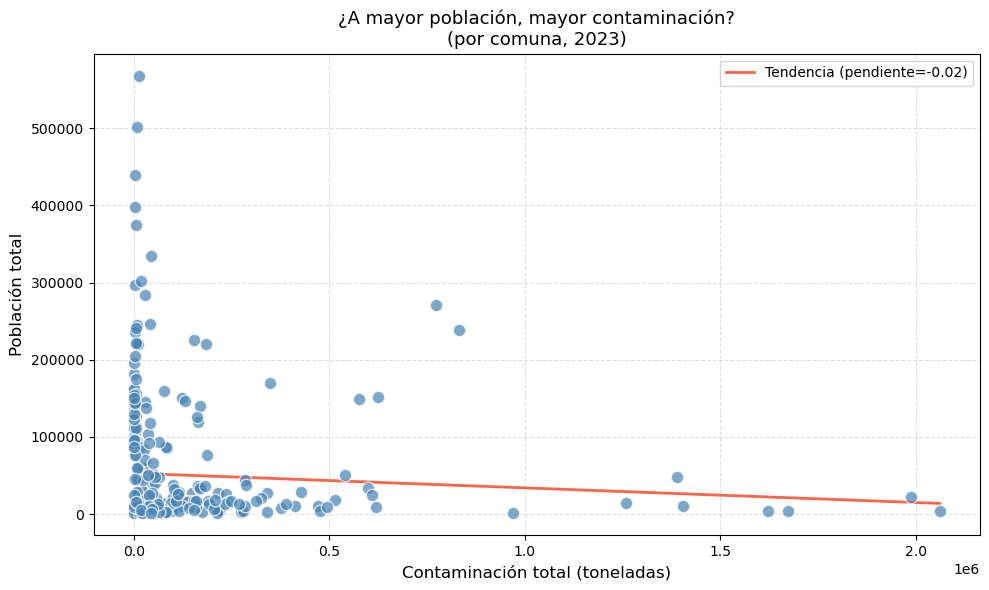

Correlación de Pearson: -0.062


In [63]:
import numpy as np

# Eliminar el punto más alejado (mayor contaminación)
outlier = union['cantidad_total_toneladas'].idxmax()
union_plot = union.drop(index=outlier)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    union_plot['cantidad_total_toneladas'],
    union_plot['poblacion_total'],
    color='steelblue', alpha=0.7, edgecolors='white', s=80, zorder=3
)

# Línea de tendencia
m, b = np.polyfit(union_plot['cantidad_total_toneladas'], union_plot['poblacion_total'], 1)
x_line = np.linspace(union_plot['cantidad_total_toneladas'].min(), union_plot['cantidad_total_toneladas'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label=f'Tendencia (pendiente={m:.2f})')



ax.set_xlabel('Contaminación total (toneladas)', fontsize=12)
ax.set_ylabel('Población total', fontsize=12)
ax.set_title('¿A mayor población, mayor contaminación?\n(por comuna, 2023)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr = union_plot['cantidad_total_toneladas'].corr(union_plot['poblacion_total'])
print(f"Correlación de Pearson: {corr:.3f}")